In [483]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [484]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [485]:
import h5py

In [501]:
data_folder = r"..\data\pilot\movement_MEPs_check"
records = os.listdir(data_folder, )
records = [record for record in records if record.find("csv") == -1]

record = records[0]
print(record)
filename_path = os.path.join(data_folder, record)

08_06TG_tms_58MSO_real.hdf


In [502]:
Fs = 5000
ms_to_samples = lambda x: int(x * Fs / 1000)

In [503]:
with h5py.File(filename_path, "r") as h5f:
    data = h5f["eeg/data"][:-1]
    stimuli = h5f["stimuli"]["messages"][()]

In [504]:
emg = - data[:, 0]# * 1e3

def get_trigger(data, bit=0):
    ttl = np.array(data, dtype=np.uint8)
    return ((ttl>>bit) & 0b1).astype(int)

trigger = get_trigger(data[:, -1])

In [505]:
from scipy.signal import iirnotch, tf2sos, butter, sosfilt, sosfilt_zi

def calculate_tkeo(x):
    x = np.asarray(x)
    tkeo = np.zeros_like(x)
    tkeo[1:-1] = x[1:-1]**2 - x[:-2] * x[2:]
    tkeo[0] = tkeo[1]
    tkeo[-1] = tkeo[-2]
    return tkeo

def make_online_filters(fs=5000, Wn=[10, 450]):
    notch_fr = 50
    notch_width = 1
    Q = notch_fr / notch_width
    b_notch, a_notch = iirnotch(notch_fr, Q, fs=fs)
    sos_notch = tf2sos(b_notch, a_notch)

    sos_butter = butter(
        N=4,
        Wn=Wn,
        btype="bandpass",
        output="sos",
        fs=fs,
    )
    return sos_notch, sos_butter

# фильтруем сигналы
sos_notch, sos_butter = make_online_filters()
emg_f = sosfilt(sos_notch, emg, axis=0)
emg_f = sosfilt(sos_butter, emg_f, axis=0)

In [506]:
def get_epochs(emg, trigger, start_ms, end_ms):
    trigger_diff = np.diff(trigger)
    events = np.where(trigger_diff == 1)[0]

    def cut_epoch(timepoint, data, start, end):
        return data[timepoint+start:timepoint+end]

    start = ms_to_samples(start_ms)
    end = ms_to_samples(end_ms)
    time = np.linspace(start_ms, end_ms, end-start)
    epochs = np.asarray([cut_epoch(timestamp, emg, start, end) for timestamp in events])

    tkeo_epochs = np.asarray([calculate_tkeo(epoch*1e-3) for epoch in epochs])

    return time, epochs, tkeo_epochs 

start_ms = -500
end_ms = 300

time, epochs, tkeo_epochs = get_epochs(emg_f *1e3, trigger, start_ms, end_ms)

In [531]:
def plot_epochs(time, data, mep_limits=(15, 50), art_limits=(-2, 8), bas_corr=False, ax = None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, fisize=(4, 3))
    time = np.asarray(time)
    data = np.asarray(data)

    def baseline_correction(epochs, time, from_ms=start_ms, to_ms=start_ms + 50):
        mask = np.where((time > from_ms) & (time<to_ms))[0]
        baseline_mean = np.mean(epochs[:, mask], axis=1)
        return epochs - baseline_mean.reshape((-1, 1))
    
    if bas_corr:
        data = baseline_correction(data, time)

    signal_masks = [
        time < art_limits[0],
        (time > art_limits[1]) & (time < mep_limits[0]),
        time > mep_limits[1],
    ]

    first_lines = []
    for i in range(data.shape[0]):
        line, = ax.plot(time[signal_masks[0]], data[i, signal_masks[0]])
        first_lines.append(line)

    colors = [line.get_color() for line in first_lines]

    for mask in signal_masks[1:]:
        for i in range(data.shape[0]):
            ax.plot(time[mask], data[i, mask], color=colors[i])

    art_mask = (time >= art_limits[0]) & (time <= art_limits[1])
    ax.plot(time[art_mask], data[:, art_mask].T,
             lw=0.5, color="darkgrey", alpha=0.3)

    mep_mask = (time >= mep_limits[0]) & (time <= mep_limits[1])
    ax.plot(time[mep_mask], data[:, mep_mask].T,
             lw=0.5, color="darkgrey", alpha=0.3)


Text(0, 0.5, '[mV]')

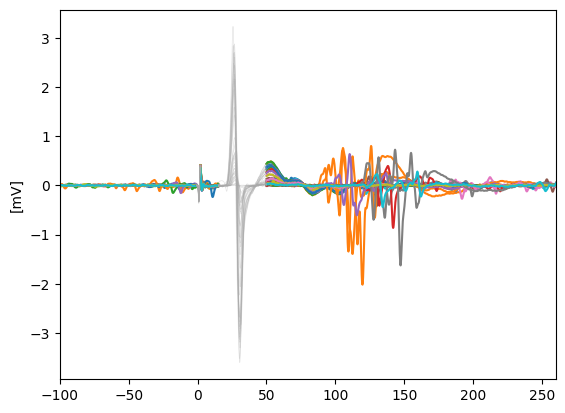

In [508]:
plot_epochs(time, epochs, mep_limits=(15, 50), art_limits=(-1, 2), bas_corr=True)
plt.xlim(-100, 260)
plt.ylabel("[mV]")

Text(0, 0.5, '[mV2]')

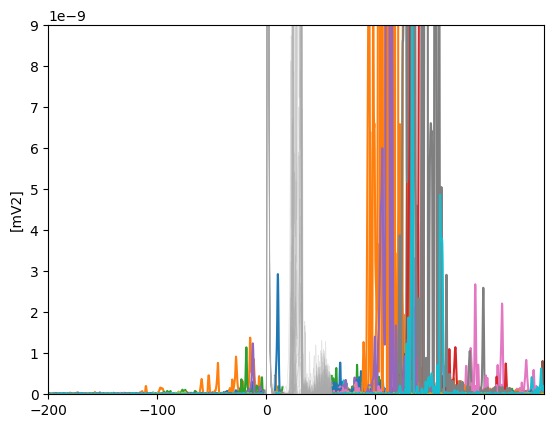

In [509]:
plot_epochs(time, tkeo_epochs, mep_limits=(15, 60), art_limits=(-1.5, 8), bas_corr=False)
plt.xlim(-200, 255)
# plt.xlim(-8, 8)

amp = 9*1e-9
thr = 2*1e-9
# plt.axhline(thr, color="black")
plt.ylim(0, amp)
plt.ylabel("[mV2]")

In [510]:
def find_onset(epoch, thr, time):
    idxs = np.where(epoch >= thr)[0]
    if len(idxs) == 0:
        return np.nan
    else:
        return time[idxs[0]]

def create_mask_clear(time, mep_limits=(15, 60), art_limits=(-1, 8)):
    signal_mask = [
        time < art_limits[0],
        (time > art_limits[1]) & (time < mep_limits[0]),
        time > mep_limits[1],
    ]
    return np.any(np.asarray(signal_mask), axis=0)

thr = 2*1e-9
mask_clear = create_mask_clear(time, mep_limits=(15, 60), art_limits=(-1.5, 8))
delays = np.asarray([find_onset(epoch[mask_clear], thr, time[mask_clear]) for epoch in tkeo_epochs ])
delays

array([         nan,  94.54863716,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan, 134.15853963,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan, 128.7571893 , 191.57289322, 198.77469367,
                nan,          nan,  10.3275819 ,  92.34808702,
                nan, 129.95748937, 103.75093773,          nan,
                nan, 121.75543886,          nan, 132.75818955])

In [511]:
from scipy.signal import find_peaks


def _robust_noise_level(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("Baseline interval is empty")

    median = np.median(x)
    mad = np.median(np.abs(x - median))
    sigma = 1.4826 * mad

    if sigma <= np.finfo(float).eps:
        sigma = max(
            np.std(x),
            np.percentile(x, 75) - np.percentile(x, 25),
            np.finfo(float).eps,
        )

    return median, sigma


def _smooth_boxcar(x, time, window_ms):
    dt = np.median(np.diff(time))
    n_samples = max(1, int(round(window_ms / dt)))
    if n_samples <= 1:
        return x.copy()
    kernel = np.ones(n_samples) / n_samples
    return np.convolve(x, kernel, mode="same")


def detect_movement_in_epoch(
    time,
    emg_tkeo,
    baseline=(-500, -300),
    art_limits=(-1.5, 8),
    post_tms_ignore_until=60,
    threshold_k=8,
    baseline_percentile=99.5,
    prominence_k=4,
    smooth_ms=3,
    min_width_ms=2,
    min_distance_ms=10,
    confirmation_window_ms=8,
    required_fraction=0.25,
    detect_pre_tms=True,
):
    """
    Detect movement from TKEO-EMG.

    The threshold is estimated only from baseline. A movement is accepted
    only when it has a real peak: enough height, prominence, width, and a
    short neighborhood above threshold. This rejects isolated spikes and
    avoids the old percentile(signal) failure mode where a large movement
    raised its own detection threshold.
    """

    time = np.asarray(time)
    emg_tkeo = np.asarray(emg_tkeo)

    baseline_mask = (time >= baseline[0]) & (time <= baseline[1])
    base = emg_tkeo[baseline_mask]
    noise_median, noise_sigma = _robust_noise_level(base)

    threshold = max(
        noise_median + threshold_k * noise_sigma,
        np.percentile(base, baseline_percentile),
    )
    min_prominence = max(
        prominence_k * noise_sigma,
        0.5 * (threshold - noise_median),
    )

    valid_mask = time > post_tms_ignore_until
    if detect_pre_tms:
        valid_mask |= time < art_limits[0]

    signal_smooth = _smooth_boxcar(emg_tkeo, time, smooth_ms)
    signal_for_peaks = signal_smooth.copy()
    signal_for_peaks[~valid_mask] = noise_median

    dt = np.median(np.diff(time))
    min_width_samples = max(1, int(round(min_width_ms / dt)))
    min_distance_samples = max(1, int(round(min_distance_ms / dt)))

    peaks, props = find_peaks(
        signal_for_peaks,
        height=threshold,
        prominence=min_prominence,
        width=min_width_samples,
        distance=min_distance_samples,
    )

    half_window = max(1, int(round((confirmation_window_ms / 2) / dt)))
    accepted = []
    accepted_prop_idxs = []
    fraction_by_peak = []

    for prop_idx, peak_idx in enumerate(peaks):
        lo = max(0, peak_idx - half_window)
        hi = min(len(signal_smooth), peak_idx + half_window + 1)
        local_idxs = np.arange(lo, hi)
        local_idxs = local_idxs[valid_mask[local_idxs]]

        if local_idxs.size == 0:
            continue

        fraction = np.mean(signal_smooth[local_idxs] > threshold)
        if fraction >= required_fraction:
            accepted.append(peak_idx)
            accepted_prop_idxs.append(prop_idx)
            fraction_by_peak.append(fraction)

    movement_found = len(accepted) > 0
    onset_time = np.nan
    peak_time = np.nan
    peak_amp = np.nan
    peak_prominence = np.nan
    peak_times = []
    peak_amps = []
    fraction_max = 0 if len(fraction_by_peak) == 0 else np.max(fraction_by_peak)

    if movement_found:
        peak_times = time[accepted].tolist()
        peak_amps = signal_smooth[accepted].tolist()

        peak_idx = accepted[0]
        prop_idx = accepted_prop_idxs[0]
        peak_time = time[peak_idx]
        peak_amp = signal_smooth[peak_idx]
        peak_prominence = props["prominences"][prop_idx]

        segment_start = peak_idx
        while segment_start > 0 and valid_mask[segment_start - 1]:
            segment_start -= 1

        above_before_peak = np.where(
            (signal_smooth[segment_start:peak_idx + 1] > threshold) &
            valid_mask[segment_start:peak_idx + 1]
        )[0]
        if len(above_before_peak) > 0:
            onset_time = time[segment_start + above_before_peak[0]]
        else:
            onset_time = peak_time

    return {
        "movement_found": movement_found,
        "onset_time": onset_time,
        "peak_time": peak_time,
        "peak_amp": peak_amp,
        "peak_prominence": peak_prominence,
        # "peak_times": peak_times,
        # "peak_amps": peak_amps,
        "threshold": threshold,
        "noise_median": noise_median,
        "noise_sigma": noise_sigma,
        "fraction_max": fraction_max,
        "n_peaks": len(accepted),
    }


In [538]:
df_results = []
art_limits = (-1.5, 8)
mep_limits= (15, 75)
post_tms_ignore_until = mep_limits[1]

for epoch in tkeo_epochs:
    result = detect_movement_in_epoch(
        time=time,
        emg_tkeo=epoch,
        baseline=(-500, -300),
        art_limits=art_limits,
        post_tms_ignore_until=post_tms_ignore_until,
        threshold_k=15,
        baseline_percentile=99.5,
        prominence_k=4,
        smooth_ms=3,
        min_width_ms=2,
        min_distance_ms=10,
        confirmation_window_ms=8,
        required_fraction=0.25,
        detect_pre_tms=True,
    )
    df_results.append(result)

df_results = pd.DataFrame(df_results)
df_results["n_epoch"] = np.arange(1, df_results.shape[0] + 1)

df_results["movement_found"].sum()


np.int64(17)

Text(0, 0.5, '[mV]')

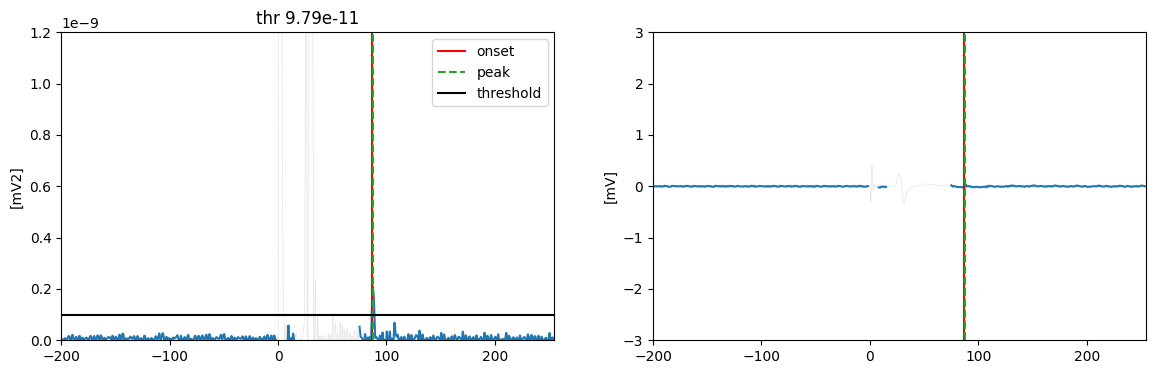

In [547]:
n_epoch = 4

fig, axis = plt.subplots(1, 2, figsize=(14, 4))
ax = axis[0]
plot_epochs(time, tkeo_epochs[n_epoch:n_epoch + 1], mep_limits=mep_limits, art_limits=art_limits, bas_corr=False, ax=ax)
ax.set_xlim(-200, 255)
# plt.xlim(-10, 80)

thr = df_results["threshold"].values[n_epoch]
onset = df_results["onset_time"].values[n_epoch]
peak = df_results["peak_time"].values[n_epoch]
ax.set_title(f"thr {thr:.2e}")

if np.isfinite(onset):
    ax.axvline(onset, color="red", label="onset")
if np.isfinite(peak):
    ax.axvline(peak, color="tab:green", ls="--", label="peak")

ax.axhline(thr, color="black", label="threshold")
# plt.ylim(9*1e-11)
ax.set_ylim(0, max(12e-10, thr * 1.4))
ax.set_ylabel("[mV2]")
ax.legend()

###########################################################
ax = axis[1]
plot_epochs(time, epochs[n_epoch:n_epoch + 1], mep_limits=mep_limits, art_limits=art_limits, bas_corr=False, ax=ax)
ax.set_xlim(-200, 255)

if np.isfinite(onset):
    ax.axvline(onset, color="red", label="onset")
if np.isfinite(peak):
    ax.axvline(peak, color="tab:green", ls="--", label="peak")

amp = 3
plt.ylim(-amp, amp)
# ax.set_ylim(0, max(12e-10, thr * 1.4))
ax.set_ylabel("[mV]")

In [536]:
df_results

,movement_found,onset_time,peak_time,peak_amp,peak_prominence,threshold,noise_median,noise_sigma,fraction_max,n_peaks,n_epoch
0,False,NaN,NaN,NaN,NaN,9.127321e-11,5.021556e-12,5.750110e-12,0.000000,0,1
1,True,89.747437,109.152288,5.851503e-08,4.352620e-08,9.094732e-11,4.968481e-12,5.731923e-12,1.000000,3,2
2,False,NaN,NaN,NaN,NaN,9.332035e-11,5.279073e-12,5.869419e-12,0.000000,0,3
3,False,NaN,NaN,NaN,NaN,9.250383e-11,6.204997e-12,5.753255e-12,0.000000,0,4
4,True,86.546637,87.746937,1.542953e-10,1.574765e-10,9.788254e-11,5.753495e-12,6.141936e-12,0.292683,1,5
5,False,NaN,NaN,NaN,NaN,8.931515e-11,4.961953e-12,5.623546e-12,0.000000,0,6
6,False,NaN,NaN,NaN,NaN,9.306122e-11,5.535204e-12,5.835068e-12,0.000000,0,7
7,False,NaN,NaN,NaN,NaN,9.928594e-11,5.332519e-12,6.263561e-12,0.000000,0,8
8,False,NaN,NaN,NaN,NaN,1.140789e-10,6.238772e-12,7.189341e-12,0.000000,0,9
9,False,NaN,NaN,NaN,NaN,8.991244e-11,4.887425e-12,5.668334e-12,0.000000,0,10
